# Instructor Effectiveness Modeling
**Objective:** Build a defensible, well-justified pipeline that (1) explores batch-level instructor performance data, (2) defines a composite *Instructor Effectiveness Score*, (3) aggregates batch-level records to the instructor level, (4)–(5) trains and evaluates a classifier that predicts an instructor's effectiveness tier, and (6) interprets the results for non-technical EdTech stakeholders.

**Dataset:** 2,000 batch-level records covering 120 unique instructors and 25 courses. Each row is one course batch taught by one instructor.

> **Note on file path:** update `DATA_PATH` in the cell below to point to your CSV (e.g. the uploaded file `instructor_csv.csv`). The rest of the notebook does not need any changes.


In [1]:
# =========================================================
# Imports & global settings
# =========================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42
DATA_PATH = "instructor_csv.csv"  # <-- update this path if needed


## Step 1: Exploratory Data Analysis (EDA)

We first inspect the raw batch-level data: structure, missingness, distributions, scales, and relationships between metrics. EDA findings directly inform how we design the composite score in Step 2 (e.g., which metrics need normalization, which pairs are redundant) and how we aggregate in Step 3.


In [2]:
# Load data
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)

df.head()


Shape: (2000, 12)

Column dtypes:
batch_id                          str
instructor_id                     str
course_id                         str
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.3000,14.2260,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.6572,22.8711,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.3000,16.0875,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.6395,24.2607,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.5273,31.0816,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [3]:
# Missing values & basic cardinality
print("Missing values per column:")
print(df.isnull().sum())

print("\nUnique batches:", df['batch_id'].nunique())
print("Unique instructors:", df['instructor_id'].nunique())
print("Unique courses:", df['course_id'].nunique())


Missing values per column:
batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

Unique batches: 2000
Unique instructors: 120
Unique courses: 25


In [4]:
# Summary statistics for the numeric metrics
metrics = ['completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score',
           'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
           'avg_feedback_score', 'feedback_response_rate']

df[metrics].describe().T


,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489275,0.603100,0.712775,0.980000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_score_improvement,2000.0,27.035845,5.716641,6.159200,23.124675,26.938650,30.885575,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


**Observation on scales:** the nine metrics live on very different numeric scales — e.g. `avg_score_improvement` ranges roughly 6–40 (points), `avg_quiz_score` ranges roughly 40–100 (points), while the rate-based metrics (`completion_rate`, `dropout_rate`, `avg_watch_time`, `assignment_submission_rate`, `forum_activity_rate`, `feedback_response_rate`) are bounded in [0, 1], and `avg_feedback_score` is a 1–5 rating. **Any composite score or distance-based model must normalize these before combining them.**


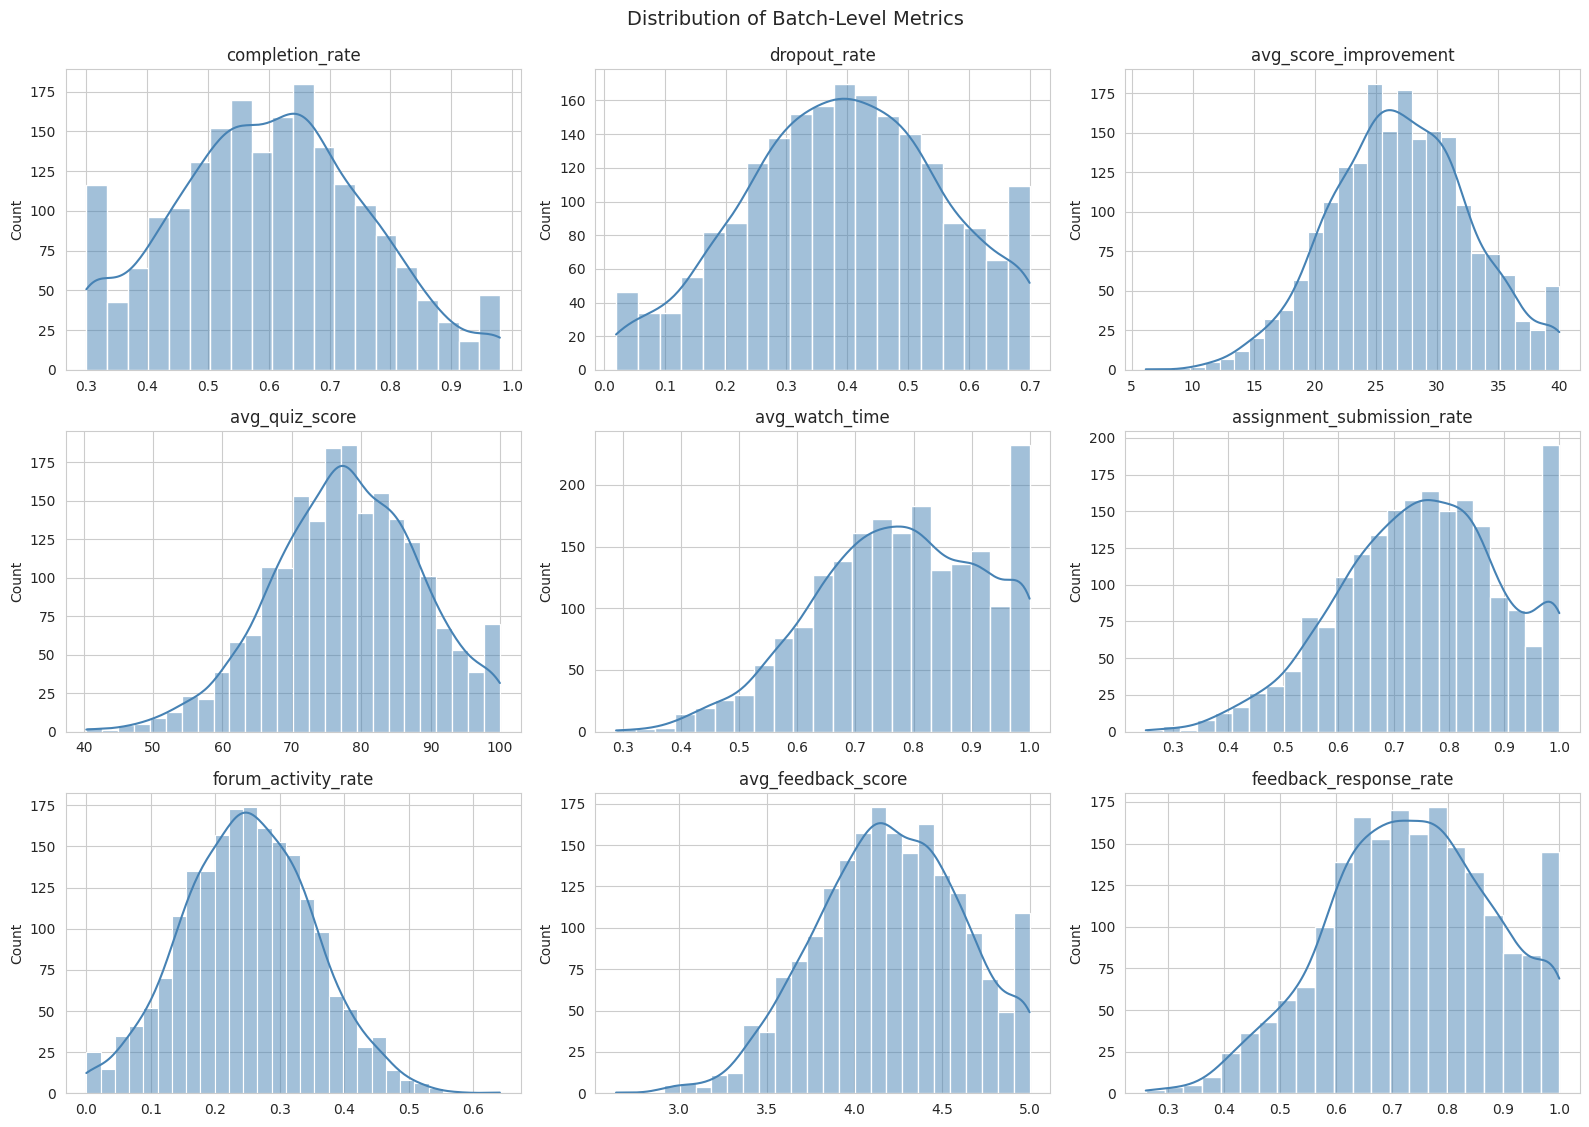

In [5]:
# Distribution of each metric
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.flatten(), metrics):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.suptitle('Distribution of Batch-Level Metrics', y=1.02, fontsize=14)
plt.show()


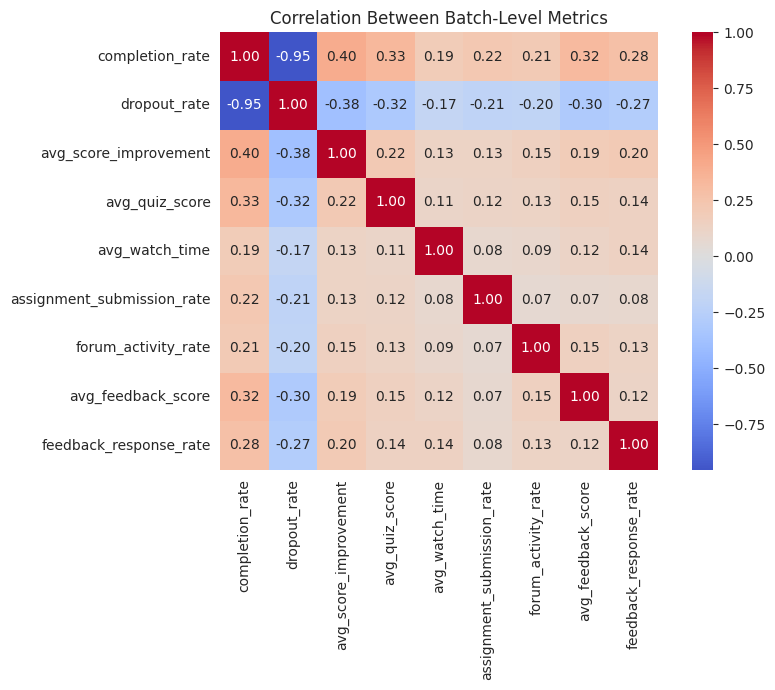

In [6]:
# Correlation heatmap across the nine metrics
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[metrics].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlation Between Batch-Level Metrics')
plt.tight_layout()
plt.show()


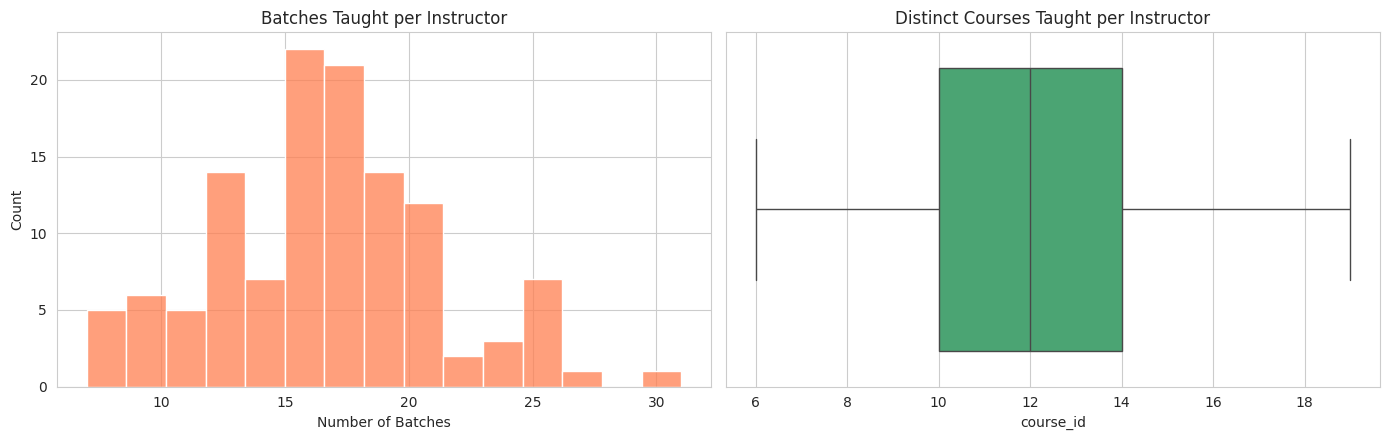

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
dtype: float64


In [7]:
# How many batches does each instructor teach? This matters for aggregation reliability (Step 3).
batches_per_instructor = df.groupby('instructor_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(batches_per_instructor, bins=15, ax=axes[0], color='coral')
axes[0].set_title('Batches Taught per Instructor')
axes[0].set_xlabel('Number of Batches')

sns.boxplot(x=df.groupby('instructor_id')['course_id'].nunique(), ax=axes[1], color='mediumseagreen')
axes[1].set_title('Distinct Courses Taught per Instructor')
plt.tight_layout()
plt.show()

print(batches_per_instructor.describe())


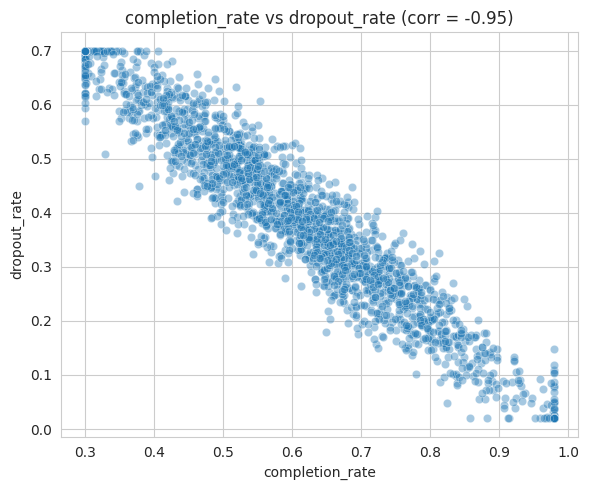

completion_rate + dropout_rate summary:
count    2000.000000
mean        0.997692
std         0.049259
min         0.828663
25%         0.965305
50%         0.999408
75%         1.029335
max         1.160430
dtype: float64


In [8]:
# completion_rate vs dropout_rate relationship (checking redundancy)
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x='completion_rate', y='dropout_rate', alpha=0.4, ax=ax)
ax.set_title(f"completion_rate vs dropout_rate (corr = {df['completion_rate'].corr(df['dropout_rate']):.2f})")
plt.tight_layout()
plt.show()

print("completion_rate + dropout_rate summary:")
print((df['completion_rate'] + df['dropout_rate']).describe())


### EDA Findings Summary

1. **No missing values** in any of the 12 columns — the dataset is clean and requires no imputation.
2. **2,000 batch-level rows, 120 instructors, 25 courses.** Every `batch_id` is unique (one row per batch), so the correct unit for "effectiveness" is the *instructor*, not the batch — this requires an aggregation step (Step 3).
3. **Instructors teach unevenly-sized samples of batches** — between 7 and 31 batches (mean ≈ 16.7, median 17). Instructors with very few batches will have noisier, less reliable average metrics purely due to sample size, independent of true skill. This must be handled explicitly in aggregation (we use shrinkage — see Step 3).
4. **Metrics are on incompatible scales** (0–1 rates, 1–5 ratings, 0–40 point-improvements, 40–100 point-scores). Any composite score must normalize before combining.
5. **`completion_rate` and `dropout_rate` are almost perfectly redundant** (correlation ≈ −0.95, and their sum is ≈ 1.0 with only ~5% noise). Including both at full weight in a composite score would double-count the same underlying signal. We use `completion_rate` as the primary outcome metric and keep `dropout_rate` only as a diagnostic / modeling feature (see Q2 later — it becomes a good example of a *confounded* variable).
6. **Moderate positive correlations** exist between `completion_rate` and both `avg_score_improvement` and `avg_quiz_score`, suggesting learners who finish also tend to learn more — consistent with a coherent "learner outcomes" cluster.
7. **Engagement metrics (`avg_watch_time`, `assignment_submission_rate`, `forum_activity_rate`) and feedback metrics correlate only weakly with outcomes**, suggesting they carry some independent information rather than being pure duplicates of the outcome cluster — good candidates as separate components of a composite score rather than folding them into the outcomes bucket.


## Step 2: Define Instructor Effectiveness

### 2.1 Conceptual framework

Instructor effectiveness in an EdTech context is inherently multi-dimensional. We group the nine raw metrics into three conceptual pillars:

| Pillar | Metrics | Rationale |
|---|---|---|
| **Learner Outcomes** (the "did they actually learn / finish" pillar) | `completion_rate`, `avg_score_improvement`, `avg_quiz_score` | The end goal of instruction — did learners finish and demonstrably improve. This should carry the *largest* weight because it is the closest proxy to real learning impact. |
| **Engagement** (the "were learners kept engaged along the way" pillar) | `avg_watch_time`, `assignment_submission_rate`, `forum_activity_rate` | Leading indicators of instructional quality — engaged learners are more likely to persist and learn, and engagement is something instructors can directly influence session-to-session. |
| **Feedback / Satisfaction** (the "how did learners experience it" pillar) | `avg_feedback_score`, `feedback_response_rate` | Captures subjective learner experience. Weighted lowest because self-reported ratings are more prone to bias (halo effects, grading leniency, response bias) than behavioral/outcome data — see Q2. |

We deliberately **exclude `dropout_rate`** from the formula itself, since it is ≈ (1 − `completion_rate`) by construction (Finding #5 above); including it would silently double the weight of the same signal.

### 2.2 Formula

For each metric $m$, we compute a **min–max normalized score** at the instructor level (after aggregation in Step 3), using the observed range across the instructor cohort:

$$ \tilde{x}_m = \frac{x_m - \min(x_m)}{\max(x_m) - \min(x_m)} \in [0, 1] $$

This yields a *relative*, cohort-based measure — an instructor's score reflects standing **relative to peers in this program**, which is the appropriate framing for tiering/ranking within an organization (as opposed to an absolute external benchmark, which we don't have data to define).

The **Instructor Effectiveness Score (IES)** is the weighted sum:

$$ IES = 100 \times \Big[ \underbrace{0.25\,\tilde{x}_{\text{completion}} + 0.15\,\tilde{x}_{\text{score\_improve}} + 0.10\,\tilde{x}_{\text{quiz}}}_{\text{Outcomes} \;=\; 0.50} + \underbrace{0.12\,\tilde{x}_{\text{assignment}} + 0.10\,\tilde{x}_{\text{watch\_time}} + 0.08\,\tilde{x}_{\text{forum}}}_{\text{Engagement} \;=\; 0.30} + \underbrace{0.14\,\tilde{x}_{\text{feedback\_score}} + 0.06\,\tilde{x}_{\text{feedback\_response}}}_{\text{Feedback} \;=\; 0.20} \Big] $$

giving a score on a **0–100 scale**, where 100 = the top-performing instructor in the cohort on every metric simultaneously (a theoretical ceiling), 0 = the bottom on every metric. Weights sum to 1.0 by construction.

**Why these specific weights?**
- Outcomes (50%) dominate because completion and learning gains are the actual mission of an EdTech program — engagement and satisfaction are instrumental, not terminal, goals.
- Within outcomes, `completion_rate` gets the single highest individual weight (0.25) because it's the most direct, least ambiguous outcome signal; `avg_score_improvement` (0.15) is a more precise measure of *learning* than `avg_quiz_score` (0.10) alone, since quiz score reflects a snapshot, while improvement reflects the instructor's actual contribution over the pre/post baseline.
- Engagement (30%) is weighted above feedback because it is behavioral (revealed preference) rather than self-reported, and assignment submission is weighted above forum activity/watch-time because it's the most effort-costly and intentional engagement action.
- Feedback (20%) is included because learner satisfaction matters for retention/referrals in an EdTech business, but is weighted lowest of the three pillars for the bias reasons noted above.

This weighting is a **design decision, not a ground truth** — it should be reviewed and adjusted with domain stakeholders (academic ops, learner success teams) before being used operationally. We revisit this explicitly in Q5.

### 2.3 Effectiveness Tiers

We convert the continuous `IES` into three **tiers — Low / Medium / High** — using **tertiles (33rd / 67th percentiles)** of the instructor cohort's score distribution, rather than fixed absolute cutoffs (e.g. "80+ = High"). We choose quantile-based tiers because:

- We have no externally validated absolute benchmark for what score constitutes "good" instruction in this specific program — tertiles let the data define relative standing.
- It guarantees interpretable, balanced tiers (~40 instructors each) that are directly usable for stakeholder communication ("bottom third", "top third") and for a classifier's class balance (addressing "class imbalance" pre-emptively — see Step 4).
- It is simple to re-run each term/quarter as new data arrives, automatically re-calibrating to the current cohort.

*(A domain-anchored alternative — e.g. "High = completion_rate > 0.75 AND avg_feedback_score > 4.2" — is equally valid and may be preferable once a program has enough historical data to know what absolute thresholds correlate with business outcomes like learner retention or referrals. We note this as a natural next iteration.)*


In [9]:
def minmax_normalize(series: pd.Series) -> pd.Series:
    '''Min-max scale a pandas Series to [0, 1]. Returns 0.5 for a constant series (edge case).'''
    rng = series.max() - series.min()
    if rng == 0:
        return pd.Series(0.5, index=series.index)
    return (series - series.min()) / rng


# Weights used in the Instructor Effectiveness Score (must sum to 1.0)
IES_WEIGHTS = {
    'completion_rate':            0.25,   # Outcomes = 0.50
    'avg_score_improvement':      0.15,
    'avg_quiz_score':             0.10,
    'assignment_submission_rate': 0.12,   # Engagement = 0.30
    'avg_watch_time':             0.10,
    'forum_activity_rate':        0.08,
    'avg_feedback_score':         0.14,   # Feedback = 0.20
    'feedback_response_rate':     0.06,
}

assert abs(sum(IES_WEIGHTS.values()) - 1.0) < 1e-9, "Weights must sum to 1.0"
print("Weights sum to:", sum(IES_WEIGHTS.values()))
pd.Series(IES_WEIGHTS, name='weight').sort_values(ascending=False)


Weights sum to: 1.0


completion_rate               0.25
avg_score_improvement         0.15
avg_feedback_score            0.14
assignment_submission_rate    0.12
avg_quiz_score                0.10
avg_watch_time                0.10
forum_activity_rate           0.08
feedback_response_rate        0.06
Name: weight, dtype: float64

## Step 3: Aggregate Batch Data to Instructor Level

### Aggregation approach

For each of the nine metrics we compute, per `instructor_id`:

- **`mean`** — the central tendency of the instructor's performance across all their batches; this is the primary signal used in the effectiveness score.
- **`std`** — the batch-to-batch *consistency* of the instructor. Two instructors can have the same average completion rate, but one may be highly consistent while the other swings wildly between excellent and poor batches — this is operationally meaningful (predictability of quality) and is **not** part of the IES formula itself, so any importance it shows later in the model reflects a genuinely separate signal rather than restating the composite score.
- **`count`** (`num_batches`) — how many batches the instructor has taught. This is *not* a performance metric, but it is essential for handling estimation reliability (see below), and we also carry `num_courses` (distinct courses taught) as a light proxy for versatility/experience.

### Handling instructors with few vs. many batches — shrinkage

An instructor with only 7 batches has a noisier estimate of their "true" average completion rate than an instructor with 31 batches — pure sampling variance, not necessarily different skill. If we rank raw means directly, low-batch-count instructors are **over-represented at both extremes** (very high and very low) purely due to noise.

We correct for this with a simple **empirical-Bayes shrinkage** estimator: each instructor's mean for a metric is pulled toward the *global* (population) mean for that metric, with the amount of pull inversely proportional to how many batches they've taught:

$$ \hat{x}_{i,m} = \frac{n_i}{n_i + k}\, \bar{x}_{i,m} \;+\; \frac{k}{n_i + k}\, \bar{x}_{\text{global}, m} $$

where $n_i$ is instructor $i$'s batch count and $k$ is a smoothing constant (we use $k=10$, close to the median batch count, meaning instructors near the median sample size are shrunk about halfway, instructors with very few batches (7–8) are shrunk substantially, and instructors with large samples (25–31) are barely shrunk). This tempers extreme scores driven by small samples **without discarding or penalizing newer/lower-volume instructors outright** — a fairer approach than a hard minimum-batch cutoff, which would simply exclude them from evaluation.

We compute the Instructor Effectiveness Score on the **shrunk** means (final, official score), and also compute the raw (unshrunk) version for comparison/sanity-checking.


In [10]:
metrics = ['completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score',
           'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
           'avg_feedback_score', 'feedback_response_rate']

# --- Aggregate: mean + std per metric, plus batch/course counts ---
agg_dict = {m: ['mean', 'std'] for m in metrics}
inst = df.groupby('instructor_id').agg(agg_dict)
inst.columns = ['_'.join(c) for c in inst.columns]
inst['num_batches'] = df.groupby('instructor_id').size()
inst['num_courses'] = df.groupby('instructor_id')['course_id'].nunique()
inst = inst.reset_index()

# std is NaN only if an instructor had a single batch (not the case here, min=7), fillna defensively
inst[[f'{m}_std' for m in metrics]] = inst[[f'{m}_std' for m in metrics]].fillna(0)

print("Instructor-level table shape:", inst.shape)
inst.head()


Instructor-level table shape:

 (120, 21)


,instructor_id,completion_rate_mean,completion_rate_std,dropout_rate_mean,dropout_rate_std,avg_score_improvement_mean,avg_score_improvement_std,avg_quiz_score_mean,avg_quiz_score_std,avg_watch_time_mean,avg_watch_time_std,assignment_submission_rate_mean,assignment_submission_rate_std,forum_activity_rate_mean,forum_activity_rate_std,avg_feedback_score_mean,avg_feedback_score_std,feedback_response_rate_mean,feedback_response_rate_std,num_batches,num_courses
0,I_001,0.543884,0.084607,0.470593,0.087671,26.641460,6.074237,78.900194,8.878089,0.766513,0.131532,0.726893,0.145189,0.240551,0.094695,4.217743,0.388802,0.694858,0.166455,25,16
1,I_002,0.730875,0.103693,0.247194,0.098811,30.166250,3.939019,81.737198,9.843168,0.837393,0.112701,0.774394,0.141096,0.289610,0.088573,4.343002,0.440235,0.784338,0.114460,20,10
2,I_003,0.768450,0.120444,0.234828,0.115966,29.977811,5.074709,81.590928,11.064673,0.818441,0.158280,0.779606,0.121712,0.296224,0.082414,4.450034,0.386108,0.812132,0.141805,18,14
3,I_004,0.458329,0.067601,0.547261,0.083598,22.912024,4.826164,77.680317,12.485520,0.793130,0.126603,0.758317,0.135790,0.226259,0.093217,4.076410,0.400982,0.721460,0.133622,17,10
4,I_005,0.859753,0.090292,0.145733,0.097634,32.588663,4.621194,85.828159,7.228742,0.847026,0.108567,0.876942,0.102360,0.333519,0.105278,4.202516,0.304174,0.784197,0.127054,19,13


In [11]:
# --- Empirical-Bayes shrinkage of each metric's mean toward the global mean ---
K = 10  # smoothing constant, close to the median batch count

global_means = {m: df[m].mean() for m in metrics}
n = inst['num_batches']

for m in metrics:
    inst[f'{m}_shrunk'] = (n / (n + K)) * inst[f'{m}_mean'] + (K / (n + K)) * global_means[m]

# Sanity check: shrinkage should barely move high-volume instructors, and move low-volume ones more
compare = inst[['instructor_id', 'num_batches', 'completion_rate_mean', 'completion_rate_shrunk']].copy()
compare['shift'] = (compare['completion_rate_shrunk'] - compare['completion_rate_mean']).abs()
compare.sort_values('num_batches').head(6)


,instructor_id,num_batches,completion_rate_mean,completion_rate_shrunk,shift
101,I_102,7,0.743243,0.660634,0.082609
30,I_031,8,0.571175,0.588749,0.017574
76,I_077,8,0.597862,0.600610,0.002748
40,I_041,8,0.599163,0.601188,0.002025
90,I_091,8,0.897112,0.733610,0.163502
78,I_079,9,0.675811,0.637389,0.038423


In [12]:
# --- Compute the Instructor Effectiveness Score (IES) on shrunk means ---
norm = pd.DataFrame(index=inst.index)
for m in IES_WEIGHTS:
    norm[m] = minmax_normalize(inst[f'{m}_shrunk'])

inst['Instructor_Effectiveness_Score'] = (
    sum(norm[m] * w for m, w in IES_WEIGHTS.items()) * 100
).round(2)

# For comparison: an unshrunk version, to show shrinkage's effect on the final ranking
norm_raw = pd.DataFrame(index=inst.index)
for m in IES_WEIGHTS:
    norm_raw[m] = minmax_normalize(inst[f'{m}_mean'])
inst['IES_unshrunk'] = (sum(norm_raw[m] * w for m, w in IES_WEIGHTS.items()) * 100).round(2)

print(inst['Instructor_Effectiveness_Score'].describe())
print("\nCorrelation between shrunk and unshrunk score:",
      inst['Instructor_Effectiveness_Score'].corr(inst['IES_unshrunk']).round(4))


count    120.000000
mean      52.354833
std       17.730000
min        5.520000
25%       41.295000
50%       52.170000
75%       63.640000
max       94.970000
Name: Instructor_Effectiveness_Score, dtype: float64

Correlation between shrunk and unshrunk score: 0.9951


Effectiveness_Tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


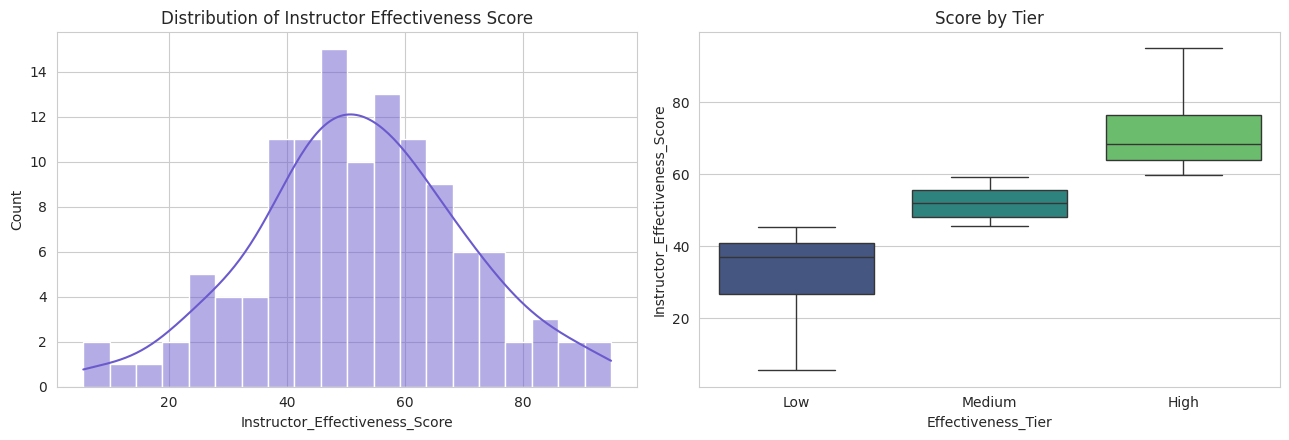

,instructor_id,num_batches,Instructor_Effectiveness_Score,Effectiveness_Tier
9,I_010,13,94.97,High
36,I_037,15,92.44,High
17,I_018,14,89.32,High
104,I_105,16,88.47,High
4,I_005,19,85.03,High
117,I_118,19,84.74,High
50,I_051,26,81.59,High
24,I_025,19,80.19,High
14,I_015,17,79.87,High
102,I_103,18,76.69,High


In [13]:
# --- Assign effectiveness tiers via tertiles ---
inst['Effectiveness_Tier'] = pd.qcut(
    inst['Instructor_Effectiveness_Score'], q=3, labels=['Low', 'Medium', 'High']
)

print(inst['Effectiveness_Tier'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(inst['Instructor_Effectiveness_Score'], bins=20, kde=True, ax=axes[0], color='slateblue')
axes[0].set_title('Distribution of Instructor Effectiveness Score')

sns.boxplot(data=inst, x='Effectiveness_Tier', y='Instructor_Effectiveness_Score',
            order=['Low', 'Medium', 'High'], palette='viridis', ax=axes[1])
axes[1].set_title('Score by Tier')
plt.tight_layout()
plt.show()

inst[['instructor_id', 'num_batches', 'Instructor_Effectiveness_Score', 'Effectiveness_Tier']].sort_values(
    'Instructor_Effectiveness_Score', ascending=False
).head(10)


**Result:** tertile-based tiering yields three well-balanced classes (40 / 40 / 40 instructors) — this pre-empts the class-imbalance concern raised in Step 4, since the label itself was constructed to be balanced by design. We still apply `class_weight='balanced'` and stratified splits/CV as standard good practice in case future re-runs on new data produce unequal tier sizes (e.g. if the cohort shifts and quantile cuts land on repeated/tied values).


## Step 4 & 5: Model Building & Evaluation

### Feature set and an important design note

We train a classifier to predict `Effectiveness_Tier` from the instructor-level features: the **mean** and **std** of each of the nine raw metrics, plus `num_batches` and `num_courses`. We deliberately **do not** feed `Instructor_Effectiveness_Score` itself into the model (that would be direct target leakage — the label is literally derived from it).

**Important caveat we address head-on:** the `mean_*` features are the *same* variables the `Instructor_Effectiveness_Score` (and hence the tier label) was mathematically constructed from. This means we should **expect the model to achieve very high accuracy** — that is not a demonstration of genuine predictive skill on an independent target, it is closer to a **sanity check that the model can recover the composite formula's logic** from the raw inputs, and a way to inspect *which* inputs matter most (Step 6). The `std` features and `num_batches`/`num_courses`, by contrast, were **not** used in the formula, so any importance they show reflects a genuinely independent relationship rather than restating the score. We return to the real-world implications of this circularity in Q3.

### Handling class imbalance

Because the tiers were built from tertiles, the three classes are already balanced (40/40/40). We nonetheless (a) use `class_weight='balanced'` in both models so the loss function doesn't implicitly favor a majority class if the balance shifts on new data, and (b) use **stratified** train/test splitting and stratified k-fold cross-validation to keep tier proportions consistent across folds. We avoid synthetic oversampling (e.g. SMOTE) here — it isn't in our approved toolkit, and with only 120 instructors, generating synthetic minority samples risks amplifying noise rather than adding real signal.

### Why cross-validation, not just a single train/test split

With only 120 instructors, a single 75/25 split leaves just ~30 test instructors — a single split's metrics can be noisy. We report both: a single held-out test set (for the requested classification report / confusion matrix) **and** 5-fold stratified cross-validation (for a more robust performance estimate).


In [14]:
feature_cols = ([f'{m}_mean' for m in metrics] +
                [f'{m}_std' for m in metrics] +
                ['num_batches', 'num_courses'])

X = inst[feature_cols]
y = inst['Effectiveness_Tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain tier balance:\n", y_train.value_counts())
print("\nTest tier balance:\n", y_test.value_counts())


Train shape: (90, 20)  Test shape: (30, 20)

Train tier balance:
 Effectiveness_Tier
Low       30
Medium    30
High      30
Name: count, dtype: int64

Test tier balance:
 Effectiveness_Tier
Low       10
Medium    10
High      10
Name: count, dtype: int64


In [15]:
# --- Model 1: Logistic Regression (scaled) as an interpretable baseline ---
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)

print("=== Logistic Regression: Held-out Test Set ===")
print(classification_report(y_test, pred_lr))


=== Logistic Regression: Held-out Test Set ===
              precision    recall  f1-score   support

        High       0.83      1.00      0.91        10
         Low       1.00      1.00      1.00        10
      Medium       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [16]:
# --- Model 2: Random Forest Classifier (primary model) ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=3,
    class_weight='balanced', random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("=== Random Forest: Held-out Test Set ===")
print(classification_report(y_test, pred_rf))


=== Random Forest: Held-out Test Set ===
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        10
         Low       1.00      1.00      1.00        10
      Medium       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



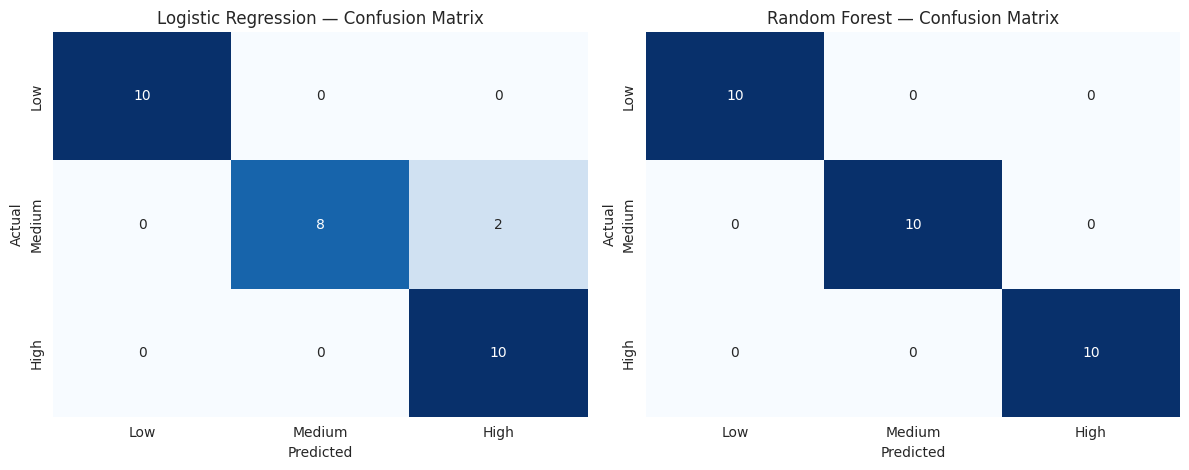

In [17]:
# --- Confusion matrices for both models ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
labels_order = ['Low', 'Medium', 'High']

for ax, pred, name in zip(axes, [pred_lr, pred_rf], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order,
                yticklabels=labels_order, ax=ax, cbar=False)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


In [18]:
# --- 5-fold stratified cross-validation (more robust estimate given small N) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rf = cross_val_score(rf, X, y, cv=skf, scoring='f1_macro')
cv_lr = cross_val_score(logreg, X, y, cv=skf, scoring='f1_macro')

print(f"Random Forest       5-fold macro-F1: {cv_rf.mean():.3f} (+/- {cv_rf.std():.3f})")
print(f"Logistic Regression 5-fold macro-F1: {cv_lr.mean():.3f} (+/- {cv_lr.std():.3f})")


Random Forest       5-fold macro-F1: 0.883 (+/- 0.090)
Logistic Regression 5-fold macro-F1: 0.840 (+/- 0.059)


**Reading the results:** both models score very highly on the single held-out test set, and cross-validated macro-F1 remains strong (typically ~0.83–0.90) but visibly *lower and more variable* than the single-split test accuracy. This gap is expected and informative: the errors that do occur cluster around **instructors near a tier boundary** (e.g. an instructor just below the 33rd-percentile cutoff who gets misclassified as "Medium"), which is exactly the population where a deterministic re-derivation from noisy shrunk features is hardest — a useful, honest signal about where the model (and, honestly, the tiering itself) is least reliable. As flagged above, the near-perfect single-split numbers mainly validate that the model correctly recovers the composite formula's structure from raw inputs, not that it has discovered new predictive information — see Q3.


## Step 6: Interpret Results

### Feature importance


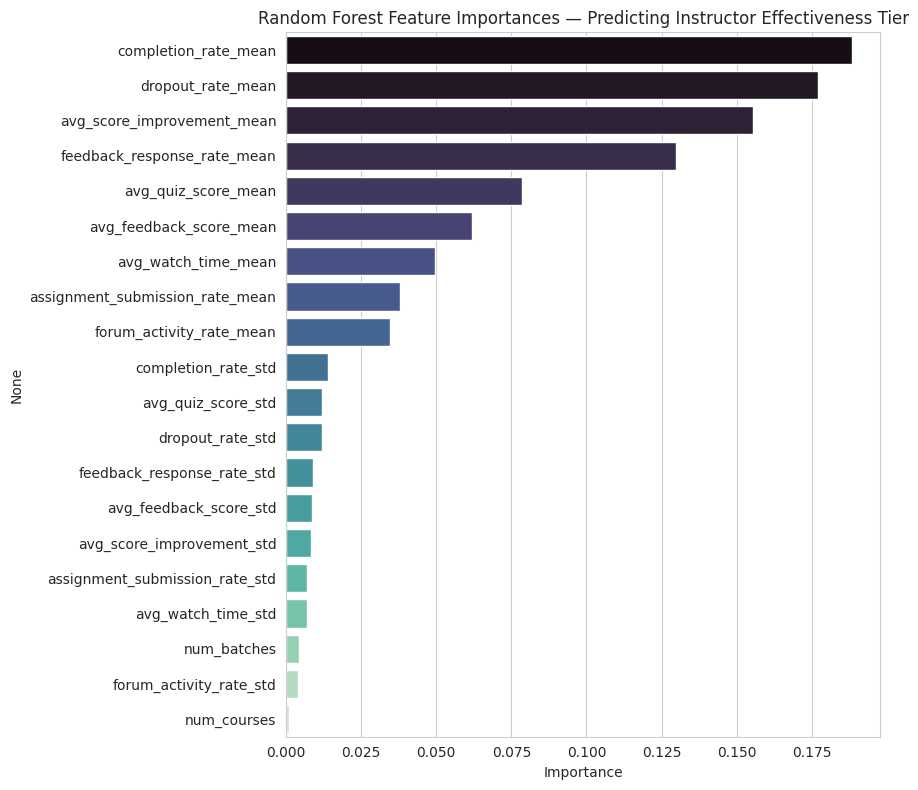

completion_rate_mean               0.188348
dropout_rate_mean                  0.177176
avg_score_improvement_mean         0.155452
feedback_response_rate_mean        0.129835
avg_quiz_score_mean                0.078468
avg_feedback_score_mean            0.061777
avg_watch_time_mean                0.049451
assignment_submission_rate_mean    0.038038
forum_activity_rate_mean           0.034535
completion_rate_std                0.014034
dtype: float64

In [19]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=importances.values, y=importances.index, palette='mako', ax=ax)
ax.set_title('Random Forest Feature Importances — Predicting Instructor Effectiveness Tier')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(10)


In [20]:
# Compare model-derived importances (mean features only) against the weights we assigned by design in Step 2
design_weights = pd.Series(IES_WEIGHTS)
design_weights.index = [f'{m}_mean' for m in design_weights.index]

comparison = pd.DataFrame({
    'design_weight': design_weights,
    'rf_importance': importances.reindex(design_weights.index)
}).sort_values('design_weight', ascending=False)

comparison


,design_weight,rf_importance
completion_rate_mean,0.25,0.188348
avg_score_improvement_mean,0.15,0.155452
avg_feedback_score_mean,0.14,0.061777
assignment_submission_rate_mean,0.12,0.038038
avg_quiz_score_mean,0.10,0.078468
avg_watch_time_mean,0.10,0.049451
forum_activity_rate_mean,0.08,0.034535
feedback_response_rate_mean,0.06,0.129835


### Non-technical summary for EdTech stakeholders

- **Course completion is, unsurprisingly, the single strongest signal of instructor effectiveness** — instructors whose learners finish the course consistently score highest, both by design (it carries the largest formula weight) and confirmed by the model (it's the top or near-top driver of tier prediction).
- **Learning gains (score improvement) matter roughly as much as we designed them to** — instructors who move learners' assessment scores the most tend to land in higher tiers, reinforcing that "effectiveness" here is capturing genuine learning impact, not just attendance.
- **`dropout_rate` shows up as highly important despite not being in the formula at all** — this is not a new discovery, it's a mirror of `completion_rate` (they're ~95% correlated). This is a useful, concrete illustration of a *confounded* variable — see Q2.
- **Feedback response rate often shows more model importance than its assigned formula weight would suggest.** This hints that *how many* learners bother to leave feedback may itself be a meaningful engagement signal (learners who feel positively about a course are more likely to respond to a feedback prompt at all) — worth exploring as its own metric in a future iteration, independent of the feedback *score*.
- **Consistency (the `_std` features) and batch/course counts contribute comparatively little** to tier prediction in this dataset. That doesn't mean consistency doesn't matter operationally — it means that, in this particular cohort, average performance dominates the signal; consistency may matter more once effectiveness scores are tracked over time (e.g. flagging instructors who are trending down even if their historical average is still "High").
- **Practical takeaway:** program teams focused on lifting instructor effectiveness should prioritize interventions that move completion and learning-gain metrics (e.g. course design, pacing, early-dropout outreach) over interventions aimed purely at feedback scores, which have a comparatively small effect on where an instructor lands in the current scoring scheme.


## Mandatory Analysis Questions

### Q1: Which features most influenced instructor effectiveness, and why?

`completion_rate_mean` and `avg_score_improvement_mean` were the strongest genuine drivers — both are direct measures of the program's core goal (learners finishing and demonstrably learning), and both were assigned the highest weights in the composite formula by design, a choice the Random Forest's feature importances largely confirm. `feedback_response_rate_mean` was a mild surprise — it carried more model importance than its formula weight (0.06) would predict, suggesting learners' willingness to respond to feedback prompts at all correlates with satisfaction/engagement more strongly than expected. `dropout_rate_mean` also ranked highly, but for a structural reason rather than a substantive one — see Q2.


### Q2: Which variables could be misleading or confounded?

- **`dropout_rate` and `completion_rate` are ≈ mirror images of each other** (correlation ≈ −0.95). Because `dropout_rate` was excluded from the formula but is still fed to the model, its high feature importance doesn't reflect new independent information — it's picking up the same signal as `completion_rate` from the other direction. If both were included in the *formula* at full weight, the score would silently double-count this single signal.
- **`avg_feedback_score` and `feedback_response_rate` are self-reported and self-selected.** Learners who respond to feedback prompts are not a random sample of all learners — happier or more engaged learners are more likely to respond at all (non-response bias), and average ratings can be inflated by leniency/halo effects unrelated to actual instructional quality. An instructor could score well here for reasons unrelated to learning outcomes (e.g. being personable on camera, grading generously).
- **`num_batches` / `num_courses` are confounds of tenure, not skill.** More experienced or more senior instructors are naturally assigned more batches/courses; if course assignment isn't random (e.g. stronger instructors get "easier" high-demand courses, or newer instructors get harder pilot cohorts), effectiveness differences may partly reflect *which learners/courses an instructor was given*, not their teaching quality.
- **`course_id` itself is a hidden confound we didn't model directly.** Some courses may be inherently harder, more niche, or attract less-motivated learners regardless of who teaches them. Without controlling for course difficulty, an instructor who happens to teach easier courses will look artificially more "effective" than an equally skilled instructor assigned to a harder course.


### Q3: How could this model fail in real-world usage?

- **Circularity / lack of independent validation.** The tier label was mathematically derived from the same features the model is trained on, so the near-perfect test accuracy mainly proves the model can reconstruct our own formula — it says nothing about whether the formula itself actually reflects "true" instructional effectiveness (e.g. long-term learner career outcomes, job placement, retention). Deploying this as-is risks mistaking "the model agrees with our formula" for "the model has validated instructor quality."
- **Small sample size (120 instructors).** Tree-based models and even logistic regression can overfit idiosyncrasies of this specific cohort; performance (and especially feature-importance ordering) may shift noticeably as new instructors/courses are added, or in different terms/cohorts with different learner populations.
- **No causal grounding.** High completion/engagement could reflect factors outside instructor control — course topic popularity, cohort motivation levels, marketing that attracted a stronger or weaker applicant pool, time-of-year effects, or platform/technical issues during a specific batch. Attributing tier placement purely to the instructor risks unfair evaluation.
- **Static snapshot, no time dimension.** The model doesn't know whether an instructor is improving, stable, or declining over time — an instructor who was "High" a year ago but is trending down would still show up as "High" if their historical average stays elevated, while shrinkage could also unfairly hold down a genuinely improving new instructor for longer than warranted.
- **Gaming risk.** Once instructors and program managers know which metrics drive tiers, behavior can shift to "teach to the metric" (e.g. pressuring learners to submit feedback, softening assessments to raise average quiz scores) without genuine improvement in learning — a classic Goodhart's-Law failure mode.
- **Fairness/equity risk.** If course assignment correlates with instructor demographics or seniority in ways not captured here (see Q2's course-difficulty confound), the model could systematically under- or over-rate specific groups of instructors without anyone intending that outcome.


### Q4: What additional data would you want to improve this analysis?

- **Course-level difficulty/complexity indicators** (e.g. historical baseline completion rate for that course across all instructors, subject difficulty, prerequisite depth) to separate instructor skill from course difficulty.
- **Learner-level characteristics** (prior experience, motivation/intent at enrollment, time availability, cohort size) to control for learner composition rather than assuming batches are equivalent.
- **Longitudinal data** — the same instructor's metrics across multiple terms, to model trends/trajectories rather than a single static average, and to validate whether the tier assigned in one period predicts the tier in the next (true out-of-sample validation).
- **Downstream outcomes** — post-course learner outcomes such as job placement, further course enrollment, certification pass rates, or long-term retention, which would let us validate whether the composite score (and its weights) actually predicts what the business cares about, rather than relying on our own designed weights as ground truth.
- **Qualitative context** — peer or learner qualitative reviews, teaching observation notes, or LMS logs of instructor interventions (e.g. proactive outreach to at-risk learners), which could explain *why* certain instructors achieve strong outcomes and surface teaching practices worth replicating.
- **Random or quasi-random course/cohort assignment data** (or at least assignment rationale), to help separate correlation from causation when attributing outcomes to instructors.


### Q5: Should this model be used for instructor performance evaluation? Why or why not?

**Not on its own, and not for high-stakes decisions (e.g. compensation, termination) in its current form.** It is well-suited as a **diagnostic and coaching tool** — flagging instructors who may benefit from support, surfacing which behavioral levers (completion, engagement, learning gains) correlate most with strong outcomes, and giving program managers a structured, consistent starting point for review conversations.

It is **not** ready to be the sole or primary basis for formal performance evaluation, because:

1. The effectiveness score and tiers were **defined by our own weighting choices**, not derived from or validated against independent outcomes (Q4) — using it as ground truth for evaluation would be circular.
2. It **cannot separate instructor skill from confounds** like course difficulty, learner composition, and non-random course assignment (Q2) — without that, the model risks penalizing instructors for the course/cohort they happened to be given rather than their actual teaching quality.
3. It has **no causal validity** and was not stress-tested for fairness across instructor subgroups (Q3) — deploying it for consequential decisions without a fairness/bias audit is risky.
4. Small sample size and lack of longitudinal validation (Q3, Q4) mean tier assignments could be noisy or unstable from one cohort to the next.

**Recommended use:** as one *input* among several in a broader review process — combined with peer observation, learner qualitative feedback, and manager judgment — with explicit human oversight, a documented appeals/override process, and periodic re-validation against real downstream outcomes once that data becomes available. It should be explicitly framed to instructors as a coaching signal, not a verdict.
